# 04 — LSTM Models for PM2.5 Prediction

Four experimental configurations run in sequence:

| # | Data | Horizon | Architecture |
|---|------|---------|-------------|
| A | 24h daily (`all_data.csv`)     | t+1 (next day)    | LSTM |
| B | 24h daily (`all_data.csv`)     | t+5 (5-day ahead) | LSTM |
| C | 1h  hourly (`all_data_1h.csv`) | t+1 (next hour)   | LSTM |
| D | 1h  hourly (`all_data_1h.csv`) | t+24 (24h ahead)  | LSTM |

**Common design decisions:**
- Train 2016–2018, test 2019 (strict temporal split)
- One global `StandardScaler` fitted on training data only
- Sequences built per station — no cross-station leakage
- `EarlyStopping` + `ReduceLROnPlateau` + `ModelCheckpoint`
- Metrics reported per forecast horizon step

**Target:** PM2.5 [µg/m³]

## 0. Imports & configuration

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

# ── Experimental configurations ───────────────────────────────────────────────
# Each dict defines one full run: data file, resolution label, lookback,
# forecast horizon, batch size and model save name.
'''
CONFIGS = [
    dict(
        label        = "A: 24h | t+1",
        csv          = "all_data.csv",
        resolution   = "daily",
        lookback     = 30,
        horizon      = 1,
        batch_size   = 64,
        save_name    = "lstm_A_24h_t1",
    ),
    dict(
        label        = "B: 24h | t+5",
        csv          = "all_data.csv",
        resolution   = "daily",
        lookback     = 30,
        horizon      = 5,
        batch_size   = 64,
        save_name    = "lstm_B_24h_t5",
    ),
    dict(
        label        = "C: 1h | t+1",
        csv          = "all_data_1h.csv",
        resolution   = "hourly",
        lookback     = 96,    # 4 days of hourly history
        horizon      = 1,
        batch_size   = 128,
        save_name    = "lstm_C_1h_t1",
    ),
    dict(
        label        = "D: 1h | t+24",
        csv          = "all_data_1h.csv",
        resolution   = "hourly",
        lookback     = 96,    # 4 days of hourly history
        horizon      = 24,    # predict next 24 hours
        batch_size   = 128,
        save_name    = "lstm_D_1h_t24",
    ),
]
'''
# For quick testing, we can reduce the number of configs or epochs.
CONFIGS = [
    dict(
        label        = "A: 24h | t+1",
        csv          = "all_data.csv",
        resolution   = "daily",
        lookback     = 7,     # only 1 week of history for faster runs
        horizon      = 1,
        batch_size   = 64,
        save_name    = "lstm_A_24h_t1",
    ),
    dict(
        label        = "B: 24h | t+5",
        csv          = "all_data.csv",
        resolution   = "daily",
        lookback     = 7,     # only 1 week of history for faster runs
        horizon      = 5,
        batch_size   = 64,
        save_name    = "lstm_B_24h_t5",
    ),
    dict(
        label        = "C: 1h | t+1",
        csv          = "all_data_1h.csv",
        resolution   = "hourly",
        lookback     = 24,    # 4 days of hourly history
        horizon      = 1,
        batch_size   = 128,
        save_name    = "lstm_C_1h_t1",
    ),
    dict(
        label        = "D: 1h | t+24",
        csv          = "all_data_1h.csv",
        resolution   = "hourly",
        lookback     = 24,    # 4 days of hourly history
        horizon      = 24,    # predict next 24 hours
        batch_size   = 128,
        save_name    = "lstm_D_1h_t24",
    ),
]

# ── Shared training hyperparameters ──────────────────────────────────────────
MAX_EPOCHS   = 2 0 # For quick testing; increase to 50-100 for final runs
PATIENCE     = 10
VAL_SPLIT    = 0.15

TRAIN_YEARS  = [2016, 2017, 2018]
TEST_YEAR    = 2019

print(f"TensorFlow : {tf.__version__}")
print(f"Configurations: {len(CONFIGS)}")
for c in CONFIGS:
    print(f"  {c['label']:20s}  lookback={c['lookback']:3d}  "
          f"horizon={c['horizon']:2d}  csv={c['csv']}")


TensorFlow : 2.20.0
Configurations: 4
  A: 24h | t+1          lookback=  7  horizon= 1  csv=all_data.csv
  B: 24h | t+5          lookback=  7  horizon= 5  csv=all_data.csv
  C: 1h | t+1           lookback= 24  horizon= 1  csv=all_data_1h.csv
  D: 1h | t+24          lookback= 24  horizon=24  csv=all_data_1h.csv


## 1. Load & prepare data

In [2]:
def load_csv(csv_path: str) -> pd.DataFrame:
    """Load and clean one of the all_data CSVs."""
    df = pd.read_csv(csv_path)
    df = df.drop(columns=[c for c in df.columns if "Unnamed" in c], errors="ignore")
    df["date"] = pd.to_datetime(df["date"])
    if df["date"].dt.tz is not None:
        df["date"] = df["date"].dt.tz_localize(None)
    df = df.dropna(subset=["pm25"])
    df = df.sort_values(["stacja", "date"]).reset_index(drop=True)
    return df


def add_calendar(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclic calendar features in-place."""
    df["month_sin"]   = np.sin(2 * np.pi * df["date"].dt.month      / 12)
    df["month_cos"]   = np.cos(2 * np.pi * df["date"].dt.month      / 12)
    df["yearday_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofyear  / 365)
    df["yearday_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofyear  / 365)
    return df


# Pre-load both CSVs once to avoid repeated disk reads
_cache: dict = {}

def get_data(csv_path: str) -> pd.DataFrame:
    if csv_path not in _cache:
        print(f"  Loading {csv_path}...")
        df = load_csv(csv_path)
        df = add_calendar(df)
        _cache[csv_path] = df
        print(f"  → {df.shape[0]:,} rows, "
              f"{df['stacja'].nunique()} stations, "
              f"{df['date'].min().date()} – {df['date'].max().date()}")
    return _cache[csv_path]


print("Data loader defined. CSVs will be loaded on first use.")


Data loader defined. CSVs will be loaded on first use.


In [3]:
# Feature columns differ between daily and hourly datasets.
# This function returns the appropriate feature list for a given resolution.

WEATHER_DAILY = [
    "temperature_2m_min", "wind_speed_10m_max", "wind_speed_10m_mean",
    "wind_direction_10m_dominant", "cloud_cover_mean", "surface_pressure_mean",
    "dew_point_2m_mean", "relative_humidity_2m_min", "boundary_layer_height",
]

WEATHER_HOURLY = [
    "temperature_2m", "wind_speed_10m", "wind_direction_10m",
    "cloud_cover", "surface_pressure", "dew_point_2m",
    "relative_humidity_2m", "precipitation", "boundary_layer_height",
]

STATION_FEATURES = [
    "lat", "lon", "elevation",
    "nearest_road_dist_m", "total_road_length_km", "building_count",
    "population", "built_up_surface", "built_up_volume",
]

CALENDAR_FEATURES = ["month_sin", "month_cos", "yearday_sin", "yearday_cos"]


def get_feature_cols(df: pd.DataFrame, resolution: str) -> list:
    """Return feature columns available in df for a given resolution."""
    weather = WEATHER_DAILY if resolution == "daily" else WEATHER_HOURLY
    all_candidates = weather + STATION_FEATURES + CALENDAR_FEATURES
    return [f for f in all_candidates if f in df.columns]


print("Feature factory defined.")


Feature factory defined.


## 2. Train / validation split & scaling

The scaler is fitted **only on training data** then applied to validation/test.  
This prevents any information from 2019 leaking into the model during training.

In [4]:
def prepare_splits(df: pd.DataFrame, feature_cols: list) -> tuple:
    """
    Split into train/test by year, fit scalers on train, return scaled slices.
    Returns (df_train_sc, df_test_sc, scaler_X, scaler_y)
    """
    TARGET = "pm25"
    df_train = df[df["date"].dt.year.isin(TRAIN_YEARS)].copy()
    df_test  = df[df["date"].dt.year == TEST_YEAR].copy()

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    scaler_X.fit(df_train[feature_cols].fillna(0))
    scaler_y.fit(df_train[[TARGET]])

    def scale(d):
        out = d.copy()
        out[feature_cols] = scaler_X.transform(d[feature_cols].fillna(0))
        out[TARGET]       = scaler_y.transform(d[[TARGET]])
        return out

    return scale(df_train), scale(df_test), scaler_X, scaler_y


print("prepare_splits() defined.")


prepare_splits() defined.


## 3. Sequence creation

Sequences are built **per station** so there is no temporal bleed between stations.  
Each sample: `X[t-LOOKBACK : t]` → `y[t : t+FORECAST_HORIZON]`.

In [5]:
def make_sequences(
    df: pd.DataFrame,
    feature_cols: list,
    target: str,
    lookback: int,
    horizon: int,
) -> tuple:
    """
    Build (X, y) sequence arrays from a long-format DataFrame.
    Sequences are created per station to avoid cross-station leakage.

    Returns
    -------
    X : float32 array of shape (n_samples, lookback, n_features)
    y : float32 array of shape (n_samples, horizon)
    """
    X_list, y_list = [], []

    for _, group in df.groupby("stacja", sort=False):
        group = group.sort_values("date").reset_index(drop=True)
        n     = len(group)

        if n < lookback + horizon:
            continue  # station too short for even one sequence

        feat   = group[feature_cols].values.astype(np.float32)
        target_vals = group[target].values.astype(np.float32)

        for i in range(n - lookback - horizon + 1):
            X_list.append(feat[i : i + lookback])
            y_list.append(target_vals[i + lookback : i + lookback + horizon])

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32),
    )

'''
print("Building sequences...")
X_train, y_train = make_sequences(df_train_sc, FEATURE_COLS, TARGET,
                                   LOOKBACK, FORECAST_HORIZON)
X_test,  y_test  = make_sequences(df_test_sc,  FEATURE_COLS, TARGET,
                                   LOOKBACK, FORECAST_HORIZON)

# Estimate memory
mem_mb = (X_train.nbytes + y_train.nbytes + X_test.nbytes + y_test.nbytes) / 1024**2

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"Memory  : {mem_mb:.1f} MB")
'''

'\nprint("Building sequences...")\nX_train, y_train = make_sequences(df_train_sc, FEATURE_COLS, TARGET,\n                                   LOOKBACK, FORECAST_HORIZON)\nX_test,  y_test  = make_sequences(df_test_sc,  FEATURE_COLS, TARGET,\n                                   LOOKBACK, FORECAST_HORIZON)\n\n# Estimate memory\nmem_mb = (X_train.nbytes + y_train.nbytes + X_test.nbytes + y_test.nbytes) / 1024**2\n\nprint(f"X_train : {X_train.shape}  y_train : {y_train.shape}")\nprint(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")\nprint(f"Memory  : {mem_mb:.1f} MB")\n'

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics_per_horizon(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    """
    Compute RMSE, MAE, R², Bias for each forecast step.
    Works for both single-step (horizon=1) and multi-step.
    """
    rows = []
    for h in range(y_true.shape[1]):
        yt = y_true[:, h]
        yp = y_pred[:, h]
        rows.append({
            "horizon": f"t+{h+1}",
            "RMSE":    np.sqrt(mean_squared_error(yt, yp)),
            "MAE":     mean_absolute_error(yt, yp),
            "R2":      r2_score(yt, yp),
            "Bias":    float(np.mean(yp - yt)),
        })
    return pd.DataFrame(rows).set_index("horizon")

## 4. Model definitions

Both models share the same output head and training procedure.

In [7]:
def build_lstm(lookback: int, n_features: int, horizon: int) -> keras.Model:
    """
    Stacked LSTM:
      LSTM(128, return_sequences=True) → Dropout(0.2)
      LSTM(64)                         → Dropout(0.2)
      Dense(horizon)
    """
    inp = keras.Input(shape=(lookback, n_features))
    x   = layers.LSTM(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.LSTM(64)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon)(x)
    return keras.Model(inp, out, name="LSTM")


print("build_lstm() defined.")


build_lstm() defined.


## 5. Training

Callbacks:
- **EarlyStopping** — stops when val_loss stops improving (patience=`PATIENCE`), restores best weights
- **ReduceLROnPlateau** — halves the learning rate after 5 stagnant epochs

In [8]:
# ── Main experiment loop ──────────────────────────────────────────────────────
# Runs all 4 configurations in sequence.
# Results are stored in `all_results` for the comparison section.

all_results   = {}   # config_label → dict with metrics, history, predictions

for cfg in CONFIGS:
    print("\n" + "=" * 60)
    print(f"CONFIG {cfg['label']}")
    print("=" * 60)

    # 1. Data
    df          = get_data(cfg["csv"])

    # --- DODAWANIE CECH CYKLICZNYCH ---
    df['date'] = pd.to_datetime(df['date'])
    # Miesiąc
    df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)
    # Dzień roku
    df['yearday_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365.25)
    df['yearday_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365.25)
    
    # Jeśli to dane godzinowe (Config C/D), warto dodać też godzinę:
    if cfg["resolution"] == "hourly":
        df['hour_sin'] = np.sin(2 * np.pi * df['date'].dt.hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['date'].dt.hour / 24)
    # ---------------------------------

    
    feat_cols   = get_feature_cols(df, cfg["resolution"])
    TARGET      = "pm25"

    df_train_sc, df_test_sc, scaler_X, scaler_y = prepare_splits(df, feat_cols)

    # 2. Sequences
    X_train, y_train = make_sequences(
        df_train_sc, feat_cols, TARGET, cfg["lookback"], cfg["horizon"])
    X_test,  y_test  = make_sequences(
        df_test_sc,  feat_cols, TARGET, cfg["lookback"], cfg["horizon"])

    mem_mb = (X_train.nbytes + y_train.nbytes +
              X_test.nbytes  + y_test.nbytes) / 1024**2
    print(f"  X_train {X_train.shape}  X_test {X_test.shape}  "
          f"features={X_train.shape[2]}  mem={mem_mb:.0f} MB")

    # 3. Build & train
    model = build_lstm(cfg["lookback"], X_train.shape[2], cfg["horizon"])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=5, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(
            filepath=f"{cfg['save_name']}_best.keras",
            monitor="val_loss", save_best_only=True, verbose=0),
    ]

    history = model.fit(
        X_train, y_train,
        epochs           = MAX_EPOCHS,
        batch_size       = cfg["batch_size"],
        validation_split = VAL_SPLIT,
        callbacks        = cb,
        verbose          = 1,
    )

    # 4. Evaluate
    y_pred_sc   = model.predict(X_test, verbose=0)
    y_pred_real = scaler_y.inverse_transform(y_pred_sc)
    y_test_real = scaler_y.inverse_transform(y_test)

    metrics = metrics_per_horizon(y_test_real, y_pred_real)
    print(f"\n  Metrics:")
    print(metrics.round(3).to_string())

    # 5. Save
    model.save(f"{cfg['save_name']}.keras")
    joblib.dump(scaler_X, f"{cfg['save_name']}_scaler_X.pkl")
    joblib.dump(scaler_y, f"{cfg['save_name']}_scaler_y.pkl")

    all_results[cfg["label"]] = dict(
        cfg        = cfg,
        history    = history,
        metrics    = metrics,
        y_test     = y_test_real,
        y_pred     = y_pred_real,
        feat_cols  = feat_cols,
    )

print("\n" + "=" * 60)
print("All configurations complete.")



CONFIG A: 24h | t+1
  Loading all_data.csv...
  → 63,230 rows, 45 stations, 2016-01-01 – 2019-12-31
  X_train (46835, 7, 22)  X_test (15765, 7, 22)  features=22  mem=37 MB
Epoch 1/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.4779 - val_loss: 0.2397 - learning_rate: 0.0010
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.4017 - val_loss: 0.2183 - learning_rate: 0.0010
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3728 - val_loss: 0.1983 - learning_rate: 0.0010
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3507 - val_loss: 0.1889 - learning_rate: 0.0010
Epoch 5/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3302 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 6/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.3094 - val_loss: 0.1858 - learning_rate: 0.0010
Epoch 7/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.2941 - val_loss: 0.1835 - learning_rate: 0.0010
Epoch 8/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/s

## 6. Learning curves

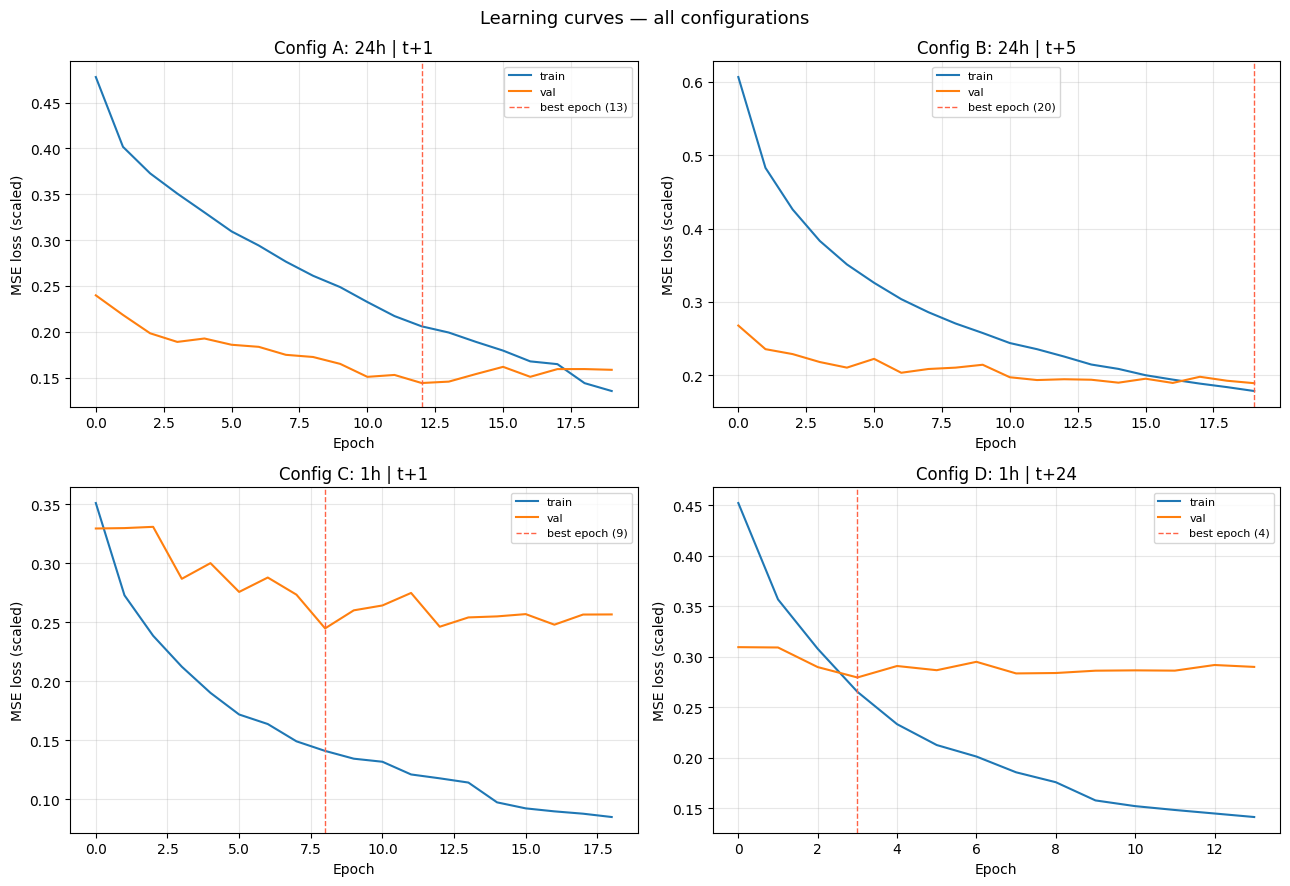

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, (label, res) in zip(axes, all_results.items()):
    h = res["history"]
    ax.plot(h.history["loss"],     label="train", linewidth=1.5)
    ax.plot(h.history["val_loss"], label="val",   linewidth=1.5)
    best = np.argmin(h.history["val_loss"])
    ax.axvline(best, color="tomato", linestyle="--",
               linewidth=1, label=f"best epoch ({best+1})")
    ax.set_title(f"Config {label}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss (scaled)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning curves — all configurations", fontsize=13)
plt.tight_layout()
plt.savefig("plot_lstm_01_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Evaluation on test set (2019)

Predictions are inverse-transformed back to µg/m³ before computing metrics.

In [10]:
import numpy as np
import pandas as pd
from tensorflow import keras
import joblib

# --- 1. Funkcje pomocnicze (muszą być zdefiniowane) ---

def predict_rescaled(model, X, scaler):
    y_pred_sc = model.predict(X, verbose=0)
    return scaler.inverse_transform(y_pred_sc)

# --- 2. Pętla automatycznej ewaluacji wszystkich konfiguracji ---

evaluation_report = {}

for cfg in CONFIGS:
    print(f"\n" + "="*60)
    print(f"EVALUATING CONFIG: {cfg['label']}")
    print("="*60)
    
    try:
        # A. Wczytanie danych surowych dla tej konkretnej konfiguracji
        df_raw = pd.read_csv(cfg['csv'], parse_dates=['date'])
        
        # --- NOWY KROK: DODANIE CECH CYKLICZNYCH ---
        # Musi być identyczny jak w pętli treningowej!
        df_raw['month_sin'] = np.sin(2 * np.pi * df_raw['date'].dt.month / 12)
        df_raw['month_cos'] = np.cos(2 * np.pi * df_raw['date'].dt.month / 12)
        df_raw['yearday_sin'] = np.sin(2 * np.pi * df_raw['date'].dt.dayofyear / 365.25)
        df_raw['yearday_cos'] = np.cos(2 * np.pi * df_raw['date'].dt.dayofyear / 365.25)
        
        if cfg["resolution"] == "hourly":
            df_raw['hour_sin'] = np.sin(2 * np.pi * df_raw['date'].dt.hour / 24)
            df_raw['hour_cos'] = np.cos(2 * np.pi * df_raw['date'].dt.hour / 24)
        # ------------------------------------------
        df_raw = df_raw.fillna(0)
        # B. Pobranie FEATURE_COLS (zakładam, że funkcja get_feature_cols jest dostępna)
        if cfg["label"] in all_results:
            feat_cols = all_results[cfg["label"]]["feat_cols"]
            print(f"Using stored feature columns ({len(feat_cols)})")
        else:
            # Failsafe: wczytaj kolumny ręcznie, jeśli restartowałeś kernel
            feat_cols = get_feature_cols(df_raw, cfg["resolution"])
            print(f"Warning: Regenerated features ({len(feat_cols)})")
        
        # C. Skalowanie i podział (używamy Twojej funkcji prepare_splits)
        # To ważne, bo musimy odtworzyć dokładnie ten sam podział i skaler co w treningu
        df_train_sc, df_test_sc, scaler_X, scaler_y = prepare_splits(df_raw, feat_cols)
        
        # D. Budowanie sekwencji testowych
        X_test, y_test = make_sequences(
            df_test_sc, feat_cols, "pm25", 
            cfg['lookback'], cfg['horizon']
        )
        
        # E. Wczytanie modelu (najlepszego zapisanego podczas treningu)
        model_path = f"{cfg['save_name']}_best.keras"
        model = keras.models.load_model(model_path)
        print(f"Loaded model: {model_path}")
        
        # F. Predykcja i powrót do jednostek rzeczywistych [µg/m³]
        y_test_real = scaler_y.inverse_transform(y_test)
        y_pred_real = predict_rescaled(model, X_test, scaler_y)
        
        # G. Obliczanie metryk
        metrics = metrics_per_horizon(y_test_real, y_pred_real)
        
        # Zapisanie wyników do raportu zbiorczego
        evaluation_report[cfg['label']] = metrics
        
        print(f"\nMetrics for {cfg['label']}:")
        print(metrics.round(3).to_string())
        
    except Exception as e:
        print(f"Error evaluating {cfg['label']}: {e}")

print("\n" + "="*60)
print("ALL EVALUATIONS COMPLETE.")


EVALUATING CONFIG: A: 24h | t+1
Using stored feature columns (22)
Loaded model: lstm_A_24h_t1_best.keras

Metrics for A: 24h | t+1:
           RMSE    MAE     R2   Bias
horizon                             
t+1      12.157  7.465  0.342  1.821

EVALUATING CONFIG: B: 24h | t+5
Using stored feature columns (22)
Loaded model: lstm_B_24h_t5_best.keras

Metrics for B: 24h | t+5:
           RMSE    MAE     R2   Bias
horizon                             
t+1      12.782  7.762  0.277  1.333
t+2      14.665  8.940  0.047  1.178
t+3      15.177  9.438 -0.026  1.393
t+4      14.981  9.321 -0.013  1.539
t+5      14.709  9.095  0.013  1.613

EVALUATING CONFIG: C: 1h | t+1
Using stored feature columns (22)
Loaded model: lstm_C_1h_t1_best.keras

Metrics for C: 1h | t+1:
           RMSE    MAE     R2   Bias
horizon                             
t+1      13.006  7.144  0.256  1.493

EVALUATING CONFIG: D: 1h | t+24
Using stored feature columns (22)
Loaded model: lstm_D_1h_t24_best.keras

Metrics for D: 1

In [11]:
'''
def predict_rescaled(model, X: np.ndarray) -> np.ndarray:
    """Predict and inverse-transform to original PM2.5 scale [µg/m³]."""
    y_pred_sc = model.predict(X, verbose=0)          # (n, horizon)
    # scaler_y was fitted on shape (n, 1) — reshape each column
    return scaler_y.inverse_transform(y_pred_sc)     # (n, horizon)


y_test_real = scaler_y.inverse_transform(y_test)     # (n, horizon)

y_pred_lstm    = predict_rescaled(model_lstm,    X_test)
y_pred_cnnlstm = predict_rescaled(model_cnnlstm, X_test)

metrics_lstm    = metrics_per_horizon(y_test_real, y_pred_lstm)
metrics_cnnlstm = metrics_per_horizon(y_test_real, y_pred_cnnlstm)

print("LSTM — test metrics per horizon:")
print(metrics_lstm.round(3).to_string())
print()
print("CNN-LSTM — test metrics per horizon:")
print(metrics_cnnlstm.round(3).to_string())
'''

'\ndef predict_rescaled(model, X: np.ndarray) -> np.ndarray:\n    """Predict and inverse-transform to original PM2.5 scale [µg/m³]."""\n    y_pred_sc = model.predict(X, verbose=0)          # (n, horizon)\n    # scaler_y was fitted on shape (n, 1) — reshape each column\n    return scaler_y.inverse_transform(y_pred_sc)     # (n, horizon)\n\n\ny_test_real = scaler_y.inverse_transform(y_test)     # (n, horizon)\n\ny_pred_lstm    = predict_rescaled(model_lstm,    X_test)\ny_pred_cnnlstm = predict_rescaled(model_cnnlstm, X_test)\n\nmetrics_lstm    = metrics_per_horizon(y_test_real, y_pred_lstm)\nmetrics_cnnlstm = metrics_per_horizon(y_test_real, y_pred_cnnlstm)\n\nprint("LSTM — test metrics per horizon:")\nprint(metrics_lstm.round(3).to_string())\nprint()\nprint("CNN-LSTM — test metrics per horizon:")\nprint(metrics_cnnlstm.round(3).to_string())\n'

## 8. Diagnostic plots

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_diagnostics(y_true, y_pred, metrics_df, model_name, save_prefix):
    """
    Generuje wykresy diagnostyczne: 
    1. Porównanie Time Series (dla pierwszego kroku prognozy)
    2. Scatter Plot (Measured vs Predicted)
    3. Histogram błędów
    """
    # Ustalamy styl
    sns.set_style("whitegrid")
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle(f"Diagnostics: {model_name}", fontsize=16)

    # Przygotowujemy dane (bierzemy t+1, czyli indeks 0, jeśli horyzont > 1)
    # y_true/y_pred mają kształt (n_samples, horizon)
    yt = y_true[:, 0]
    yp = y_pred[:, 0]
    
    # 1. Wykres serii czasowej (fragment, np. pierwsze 500 punktów dla czytelności)
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(yt[:500], label="Rzeczywiste (Measured)", color="royalblue", alpha=0.7)
    ax1.plot(yp[:500], label="Prognoza (Predicted)", color="darkorange", linestyle="--")
    ax1.set_title("Porównanie serii czasowej (t+1, fragment 500 próbek)")
    ax1.set_ylabel("PM2.5 [µg/m³]")
    ax1.legend()

    # 2. Wykres rozrzutu (Scatter Plot)
    ax2 = plt.subplot(2, 2, 3)
    max_val = max(yt.max(), yp.max())
    ax2.scatter(yt, yp, alpha=0.3, color="seagreen", s=10)
    ax2.plot([0, max_val], [0, max_val], 'r--', lw=2) # Linia 1:1
    ax2.set_xlabel("Wartości rzeczywiste")
    ax2.set_ylabel("Prognozy")
    ax2.set_title(f"Scatter Plot (R2: {metrics_df.loc['t+1', 'R2']:.3f})")

    # 3. Rozkład błędów (Error Distribution)
    ax3 = plt.subplot(2, 2, 4)
    errors = yp - yt
    sns.histplot(errors, kde=True, ax=ax3, color="crimson")
    ax3.set_title(f"Rozkład błędów (Mean Error: {errors.mean():.2f})")
    ax3.set_xlabel("Błąd [µg/m³]")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Zapisywanie
    plt.savefig(f"{save_prefix}_diagnostics.png", dpi=150)
    plt.show()
    print(f"Plot saved: {save_prefix}_diagnostics.png")

print("Function plot_diagnostics() defined.")

Function plot_diagnostics() defined.


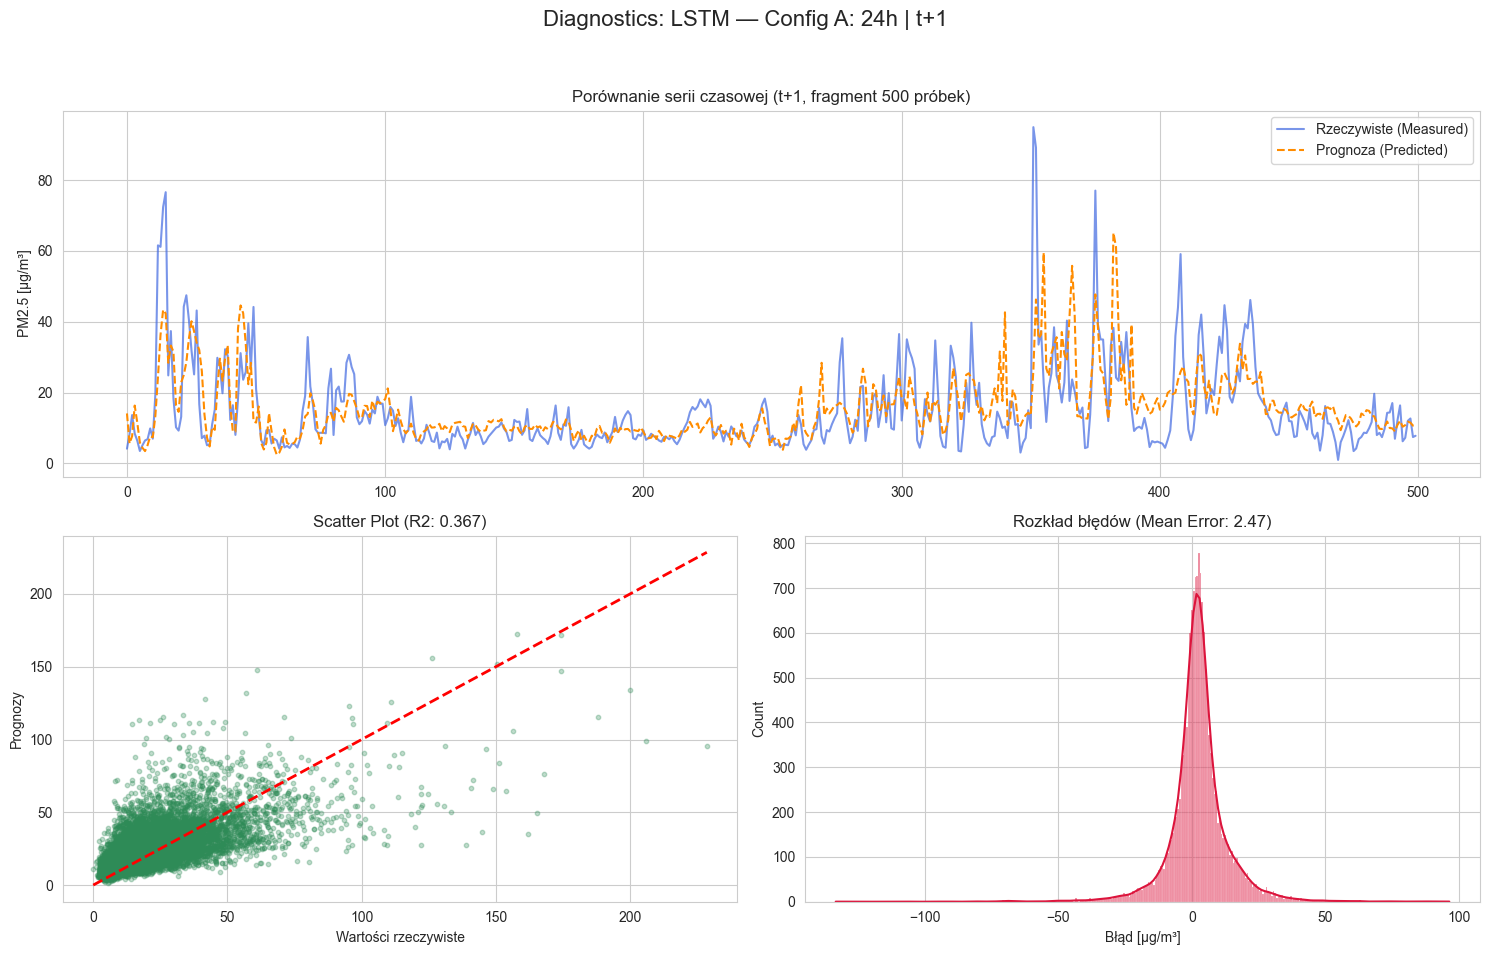

Plot saved: plot_lstm_A_diagnostics.png


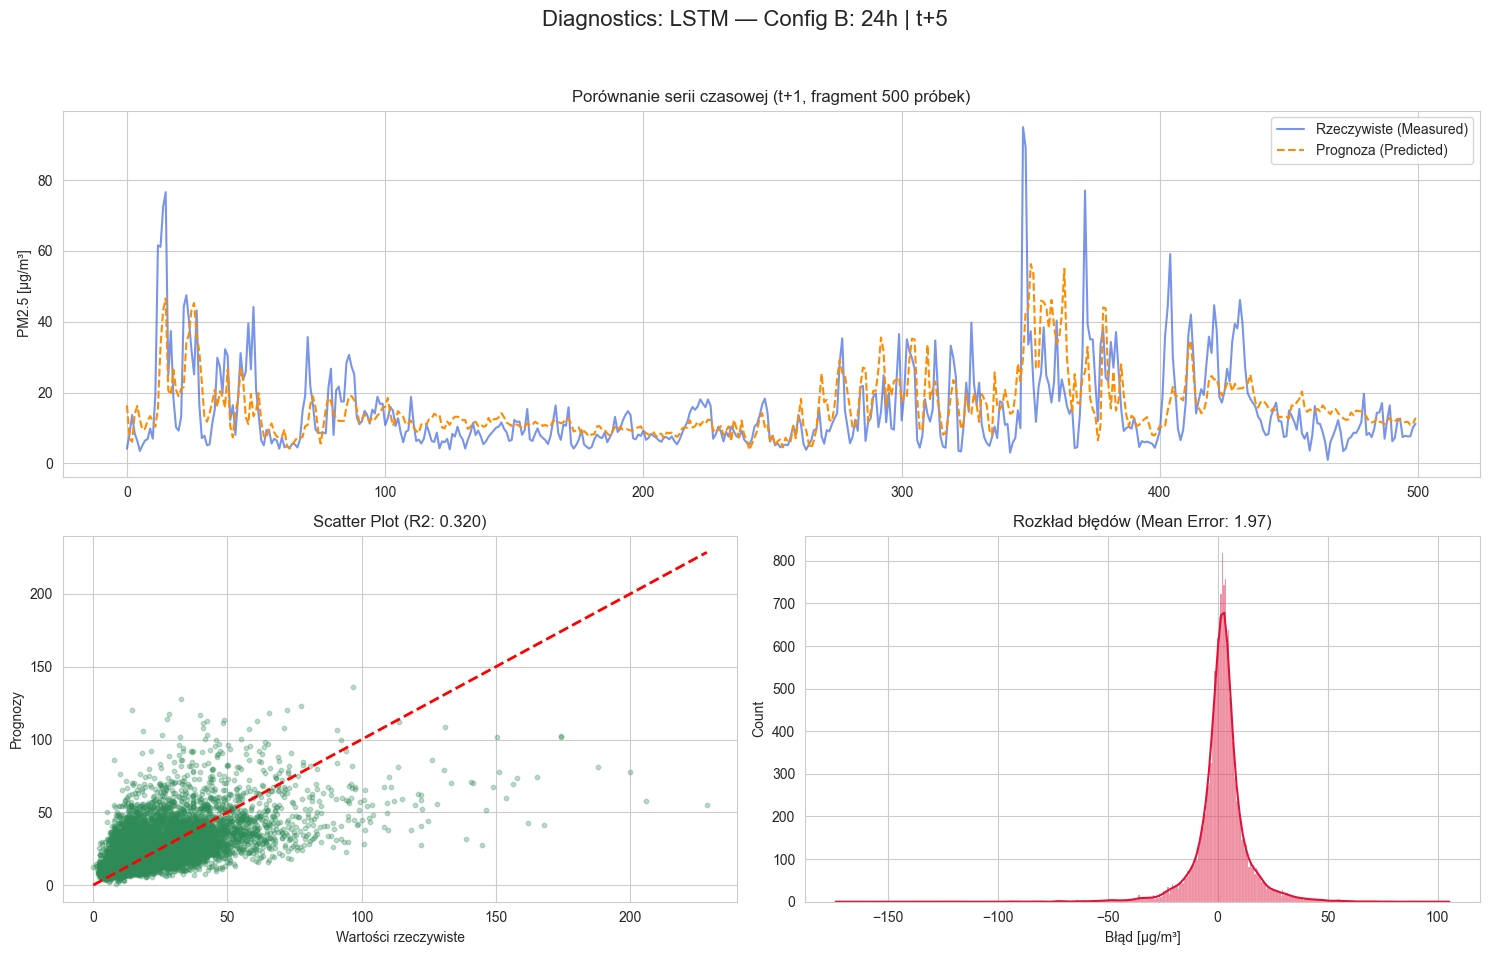

Plot saved: plot_lstm_B_diagnostics.png


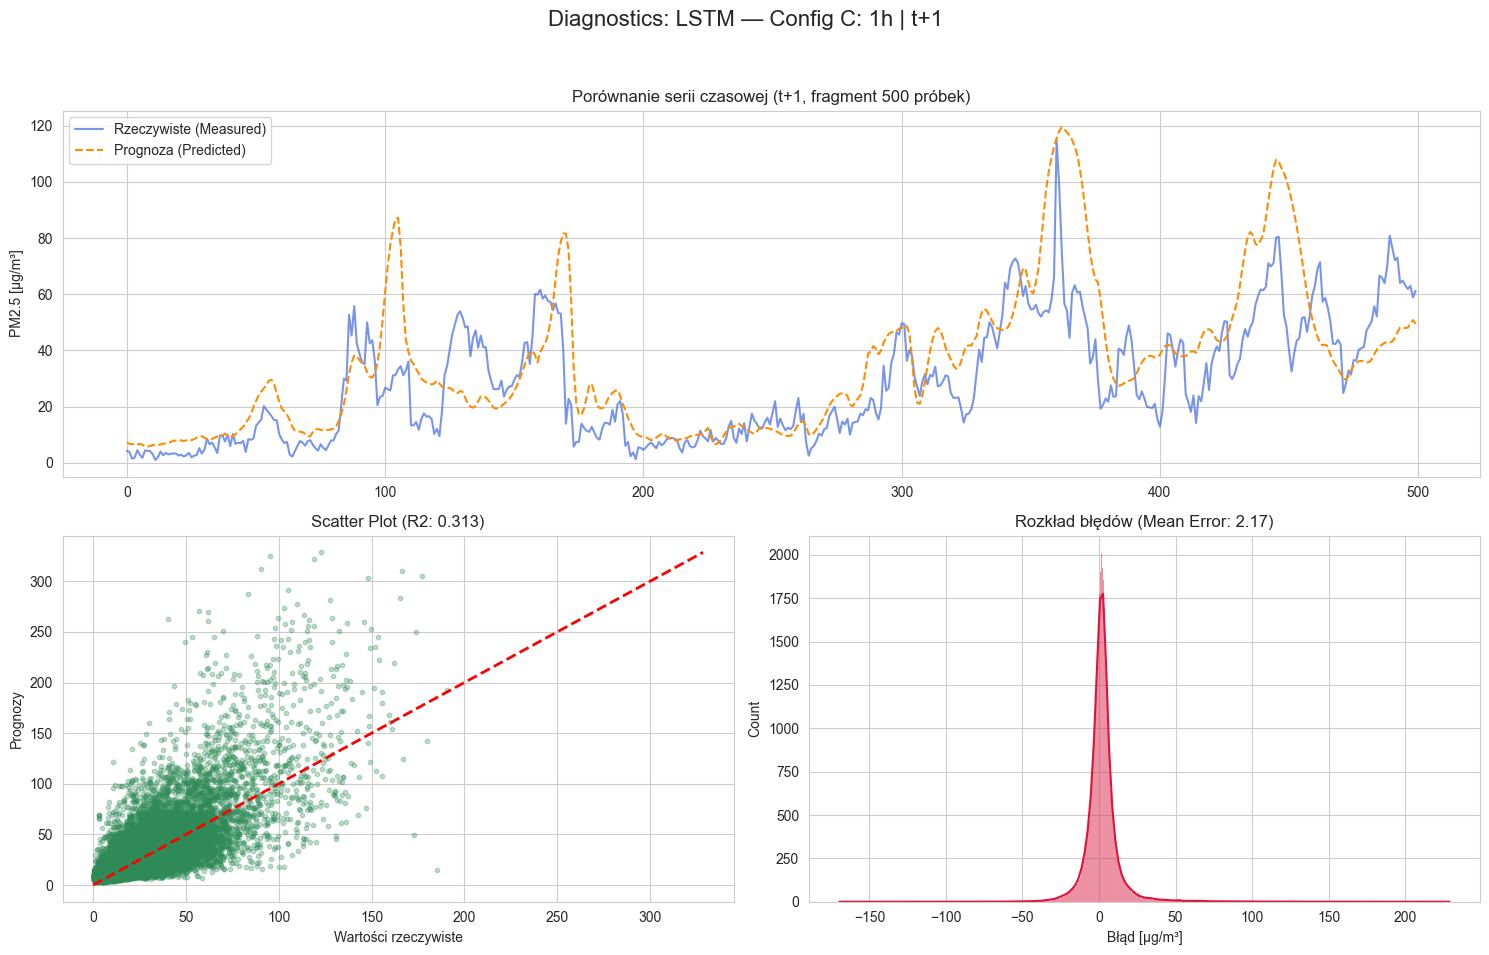

Plot saved: plot_lstm_C_diagnostics.png


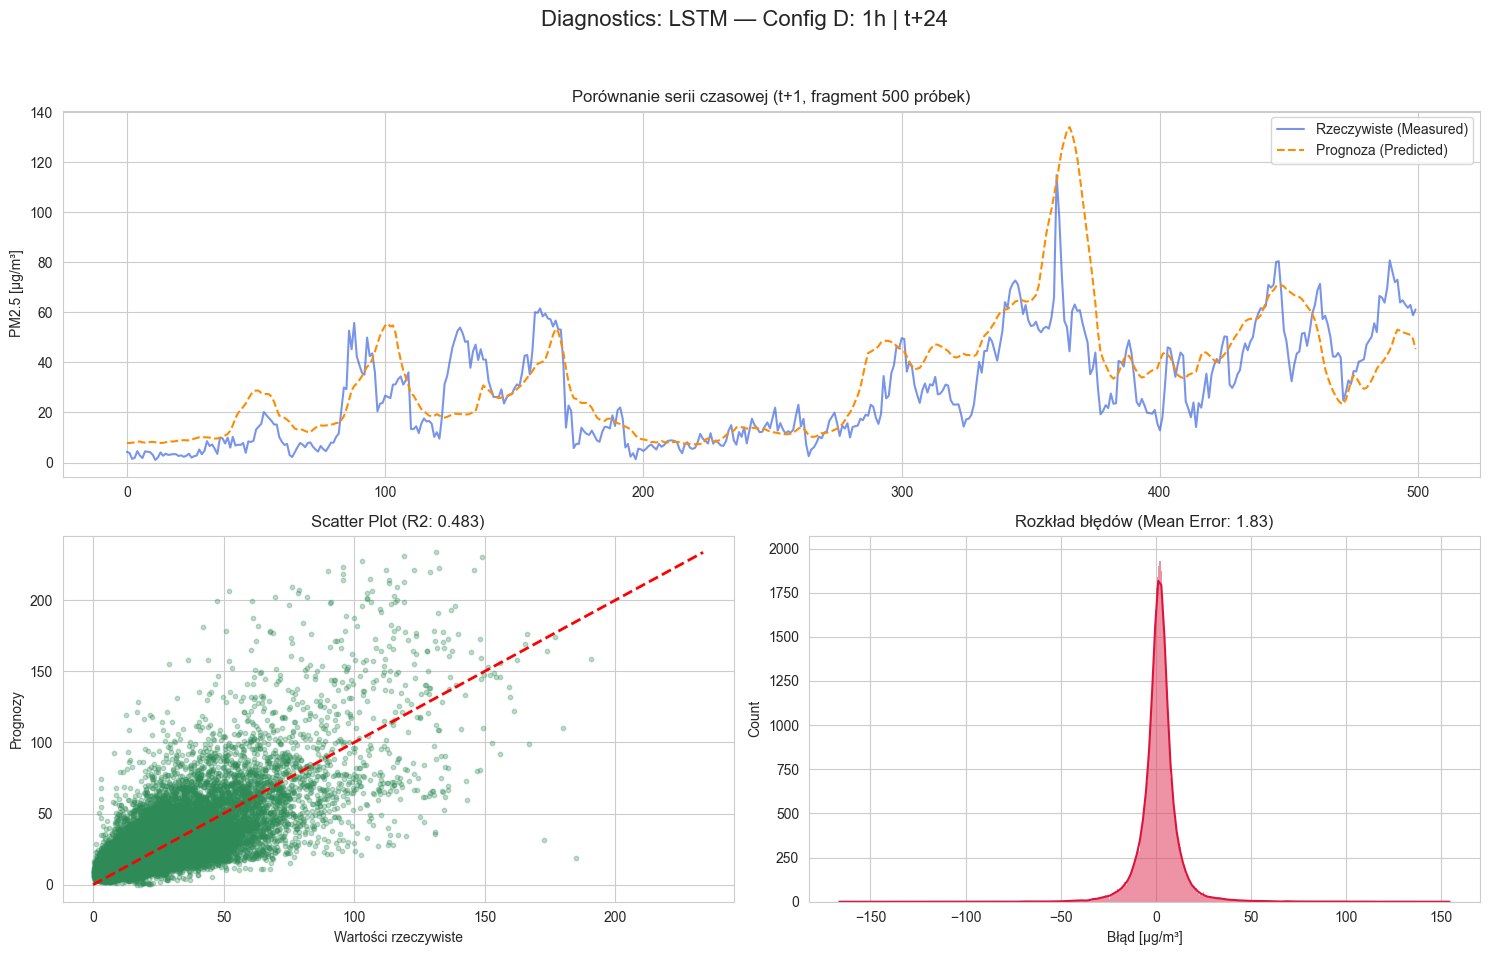

Plot saved: plot_lstm_D_diagnostics.png


In [13]:
for label, res in all_results.items():
    plot_diagnostics(
        y_true      = res["y_test"],
        y_pred      = res["y_pred"],
        metrics_df  = res["metrics"],
        model_name  = f"LSTM — Config {label}",
        save_prefix = f"plot_lstm_{label.split(':')[0].strip()}",
    )


## 9. Model comparison

MODEL COMPARISON — mean metrics across forecast horizons
              RMSE_mean  MAE_mean  R2_mean  Bias_mean  RMSE_t1  R2_t1
config                                                               
A: 24h | t+1     11.848     7.465    0.367      2.474   11.848  0.367
B: 24h | t+5     14.130     8.835    0.090      2.046   12.320  0.320
C: 1h | t+1      12.406     6.760    0.313      2.171   12.406  0.313
D: 1h | t+24     12.192     7.593    0.333      2.074   10.776  0.483


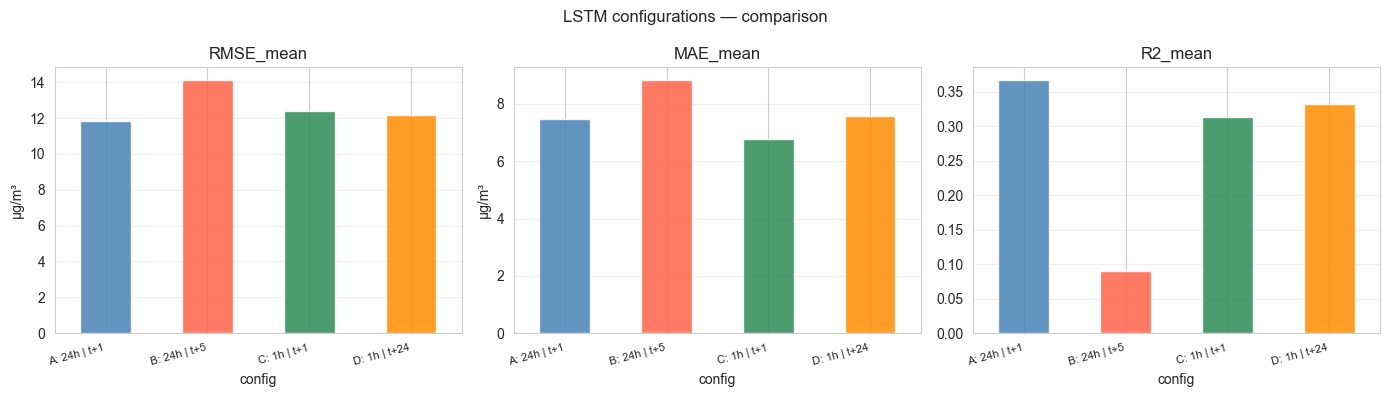

In [14]:
rows = []
for label, res in all_results.items():
    m = res["metrics"]
    rows.append({
        "config":     label,
        "RMSE_mean":  m["RMSE"].mean(),
        "MAE_mean":   m["MAE"].mean(),
        "R2_mean":    m["R2"].mean(),
        "Bias_mean":  m["Bias"].mean(),
        "RMSE_t1":    m["RMSE"].iloc[0],
        "R2_t1":      m["R2"].iloc[0],
    })

df_comparison = pd.DataFrame(rows).set_index("config")

print("=" * 60)
print("MODEL COMPARISON — mean metrics across forecast horizons")
print("=" * 60)
print(df_comparison.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE_mean", "MAE_mean", "R2_mean"]):
    df_comparison[metric].plot.bar(
        ax=ax, color=["steelblue","tomato","seagreen","darkorange"],
        alpha=0.85, edgecolor="white")
    ax.set_title(metric)
    ax.set_ylabel("µg/m³" if "RMSE" in metric or "MAE" in metric else "")
    ax.set_xticklabels(df_comparison.index, rotation=15, ha="right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("LSTM configurations — comparison", fontsize=12)
plt.tight_layout()
plt.savefig("plot_lstm_04_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Save models

In [15]:
# Models and scalers are already saved inside the training loop.
# Summary of saved files:
import os
saved = []
for cfg in CONFIGS:
    for ext in [".keras", "_best.keras", "_scaler_X.pkl", "_scaler_y.pkl"]:
        fname = cfg["save_name"] + ext
        status = "✓" if os.path.exists(fname) else "✗"
        saved.append(f"  {status} {fname}")

print("Saved model files:")
print("\n".join(saved))


Saved model files:
  ✓ lstm_A_24h_t1.keras
  ✓ lstm_A_24h_t1_best.keras
  ✓ lstm_A_24h_t1_scaler_X.pkl
  ✓ lstm_A_24h_t1_scaler_y.pkl
  ✓ lstm_B_24h_t5.keras
  ✓ lstm_B_24h_t5_best.keras
  ✓ lstm_B_24h_t5_scaler_X.pkl
  ✓ lstm_B_24h_t5_scaler_y.pkl
  ✓ lstm_C_1h_t1.keras
  ✓ lstm_C_1h_t1_best.keras
  ✓ lstm_C_1h_t1_scaler_X.pkl
  ✓ lstm_C_1h_t1_scaler_y.pkl
  ✓ lstm_D_1h_t24.keras
  ✓ lstm_D_1h_t24_best.keras
  ✓ lstm_D_1h_t24_scaler_X.pkl
  ✓ lstm_D_1h_t24_scaler_y.pkl


## 11. Summary

In [16]:
best_cfg = df_comparison["RMSE_mean"].idxmin()

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Configurations : {len(CONFIGS)}")
print(f"Train period   : {min(TRAIN_YEARS)}–{max(TRAIN_YEARS)}")
print(f"Test period    : {TEST_YEAR}")
print(f"Architecture   : stacked LSTM (128→64)")
print(f"Scaling        : global StandardScaler per config (train-only fit)")
print()
for label, res in all_results.items():
    cfg = res["cfg"]
    print(f"Config {label}:")
    print(f"  lookback={cfg['lookback']}  horizon={cfg['horizon']}  "
          f"features={len(res['feat_cols'])}")
    print(res["metrics"].round(3).to_string())
    print()
print(f"Best configuration (mean RMSE): {best_cfg}")
print()
print("Saved plots:")
for p in [
    "plot_lstm_01_learning_curves.png",
    "plot_lstm_A_diagnostics.png",
    "plot_lstm_B_diagnostics.png",
    "plot_lstm_C_diagnostics.png",
    "plot_lstm_D_diagnostics.png",
    "plot_lstm_04_comparison.png",
]:
    print(f"  {p}")


SUMMARY
Configurations : 4
Train period   : 2016–2018
Test period    : 2019
Architecture   : stacked LSTM (128→64)
Scaling        : global StandardScaler per config (train-only fit)

Config A: 24h | t+1:
  lookback=7  horizon=1  features=22
           RMSE    MAE     R2   Bias
horizon                             
t+1      11.848  7.465  0.367  2.474

Config B: 24h | t+5:
  lookback=7  horizon=5  features=22
           RMSE    MAE     R2   Bias
horizon                             
t+1      12.320  7.712  0.320  1.967
t+2      14.319  8.864  0.079  1.827
t+3      14.907  9.352 -0.004  2.037
t+4      14.722  9.241  0.009  2.171
t+5      14.381  9.007  0.047  2.229

Config C: 1h | t+1:
  lookback=24  horizon=1  features=22
           RMSE   MAE     R2   Bias
horizon                            
t+1      12.406  6.76  0.313  2.171

Config D: 1h | t+24:
  lookback=24  horizon=24  features=22
           RMSE    MAE     R2   Bias
horizon                             
t+1      10.776  6.636  0.48